# **Rainfall Prediction Dataset (UP, India, 2005-2025)**
Nguồn: https://www.kaggle.com/datasets/rupsarroy/rainfall-dataset-uttar-pradesh-20052025

Người thực hiện: Võ Bạch Kim Thịnh

# 1: Tổng quan Dữ liệu & Kiểm tra Chất lượng
Trong ô lệnh này, chúng ta sẽ tải bộ dữ liệu khí tượng từ Google Drive, kiểm tra cấu trúc tổng thể, xác định các kiểu dữ liệu, phát hiện giá trị thiếu (khuyết), kiểm tra các bản ghi bị trùng lặp và xuất thống kê mô tả chi tiết để có cái nhìn tổng quan ban đầu.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập cấu hình trực quan hóa toàn cục
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Tải bộ dữ liệu
duong_dan_du_lieu = "/content/drive/MyDrive/Data/UP_rainfall_dataset.csv"
df = pd.read_csv(duong_dan_du_lieu)

In [4]:
# 2. Hiển thị 5 dòng đầu tiên
print("--- 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ---")
df.head()

# 3. Kiểm tra cấu trúc và kiểu dữ liệu
print("\n--- CẤU TRÚC VÀ KIỂU DỮ LIỆU ---")
df.info()

--- 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ---

--- CẤU TRÚC VÀ KIỂU DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565210 entries, 0 to 565209
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 565210 non-null  int64  
 1   MO                   565210 non-null  int64  
 2   DY                   565210 non-null  int64  
 3   RH2M                 565210 non-null  float64
 4   T2MDEW               565210 non-null  float64
 5   QV2M                 565210 non-null  float64
 6   PS                   565210 non-null  float64
 7   WS50M                565210 non-null  float64
 8   PRECTOTCORR          565210 non-null  float64
 9   T2MWET               565210 non-null  float64
 10  WD50M                565210 non-null  float64
 11  T2M_MAX              565210 non-null  float64
 12  T2M_MIN              565210 non-null  float64
 13  ALLSKY_SFC_UV_INDEX  565210 non-null  float64


In [6]:
# 4. Kiểm tra giá trị khuyết (Missing Values)
print("\n--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT TRÊN MỖI CỘT ---")
print(df.isnull().sum())

# 5. Kiểm tra các bản ghi bị trùng lặp (Duplicates)
so_ban_ghi_trung = df.duplicated().sum()
print(f"\n--- SỐ BẢN GHI BỊ TRÙNG LẶP PHÁT HIỆN: {so_ban_ghi_trung} ---")



--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT TRÊN MỖI CỘT ---
YEAR                   0
MO                     0
DY                     0
RH2M                   0
T2MDEW                 0
QV2M                   0
PS                     0
WS50M                  0
PRECTOTCORR            0
T2MWET                 0
WD50M                  0
T2M_MAX                0
T2M_MIN                0
ALLSKY_SFC_UV_INDEX    0
TS                     0
PSC                    0
WSC                    0
DISTRICT               0
LATITUDE               0
LONGITUDE              0
dtype: int64

--- SỐ BẢN GHI BỊ TRÙNG LẶP PHÁT HIỆN: 7638 ---


In [7]:
# 6. Thống kê mô tả chi tiết cho các biến số
print("\n--- THỐNG KÊ MÔ TẢ CHI TIẾT ---")
print(df.describe().T)


--- THỐNG KÊ MÔ TẢ CHI TIẾT ---
                        count         mean         std      min      25%  \
YEAR                 565210.0  2014.958723    6.032998  2005.00  2010.00   
MO                   565210.0     6.500246    3.437761     1.00     4.00   
DY                   565210.0    15.726190    8.798350     1.00     8.00   
RH2M                 565210.0    52.661214   23.381653     4.43    33.12   
T2MDEW               565210.0    12.887180    9.434597   -16.99     5.32   
QV2M                 565210.0    11.081021    6.397836     0.85     5.64   
PS                   565210.0    98.983422    0.990888    94.48    98.35   
WS50M                565210.0     4.412228    1.765306     0.48     3.09   
PRECTOTCORR          565210.0     2.677751    7.594734     0.00     0.00   
T2MWET               565210.0    19.331620    7.140777    -1.68    13.34   
WD50M                565210.0   218.443396  100.207399     0.00   114.20   
T2M_MAX              565210.0    32.560436    6.746650 

# 2: Phân tích Phân phối Biến mục tiêu (PRECTOTCORR)
Các bộ dữ liệu về lượng mưa thường gặp hiện tượng "lệch phải nghiêm trọng" và "mất cân bằng do số 0" (Zero-Inflation) vì phần lớn các ngày trong năm là ngày không mưa. Tại đây, chúng ta sẽ tính toán độ lệch (skewness) và bóc tách các chỉ số thống kê riêng biệt cho tập hợp ngày có mưa và ngày không mưa.

In [8]:
# Tính toán các chỉ số thống kê cho biến mục tiêu PRECTOTCORR
tong_so_ngay = len(df)
so_ngay_khong_mua = (df['PRECTOTCORR'] == 0).sum()
so_ngay_co_mua = (df['PRECTOTCORR'] > 0).sum()
ty_le_khong_mua = (so_ngay_khong_mua / tong_so_ngay) * 100
do_lech_skewness = df['PRECTOTCORR'].skew()

print(f"Tổng số ngày quan sát: {tong_so_ngay} ngày")
print(f"Số ngày KHÔNG mưa (PRECTOTCORR = 0): {so_ngay_khong_mua} ngày ({ty_le_khong_mua:.2f}%)")
print(f"Số ngày CÓ mưa (PRECTOTCORR > 0): {so_ngay_co_mua} ngày ({100 - ty_le_khong_mua:.2f}%)")
print(f"Hệ số độ lệch (Skewness) của lượng mưa: {do_lech_skewness:.2f}")

# Thống kê mô tả phân tách
print("\n--- THỐNG KÊ MÔ TẢ: CHỈ TÍNH NHỮNG NGÀY CÓ MƯA (PRECTOTCORR > 0) ---")
print(df[df['PRECTOTCORR'] > 0]['PRECTOTCORR'].describe())

print("\n--- THỐNG KÊ MÔ TẢ: CHỈ TÍNH NHỮNG NGÀY KHÔNG MƯA (PRECTOTCORR == 0) ---")
print(df[df['PRECTOTCORR'] == 0]['PRECTOTCORR'].describe())

Tổng số ngày quan sát: 565210 ngày
Số ngày KHÔNG mưa (PRECTOTCORR = 0): 301001 ngày (53.25%)
Số ngày CÓ mưa (PRECTOTCORR > 0): 264209 ngày (46.75%)
Hệ số độ lệch (Skewness) của lượng mưa: 5.77

--- THỐNG KÊ MÔ TẢ: CHỈ TÍNH NHỮNG NGÀY CÓ MƯA (PRECTOTCORR > 0) ---
count    264209.000000
mean          5.728389
std          10.291601
min           0.010000
25%           0.240000
50%           1.640000
75%           6.700000
max         279.270000
Name: PRECTOTCORR, dtype: float64

--- THỐNG KÊ MÔ TẢ: CHỈ TÍNH NHỮNG NGÀY KHÔNG MƯA (PRECTOTCORR == 0) ---
count    301001.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: PRECTOTCORR, dtype: float64


# 3: Trực quan hóa Xu hướng Theo Thời gian
Để nắm bắt quy luật thời tiết qua các chu kỳ thời gian, chúng ta thiết lập hai biểu đồ: Biểu đồ cột thể hiện lượng mưa trung bình theo các tháng nhằm tìm ra đỉnh điểm mùa mưa (tính mùa vụ) và Biểu đồ đường thể hiện xu hướng lượng mưa trung bình qua các năm.

/tmp/ipykernel_2926/1216812220.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=luong_mua_thang, x='MO', y='PRECTOTCORR', ax=axes[0], palette='viridis')


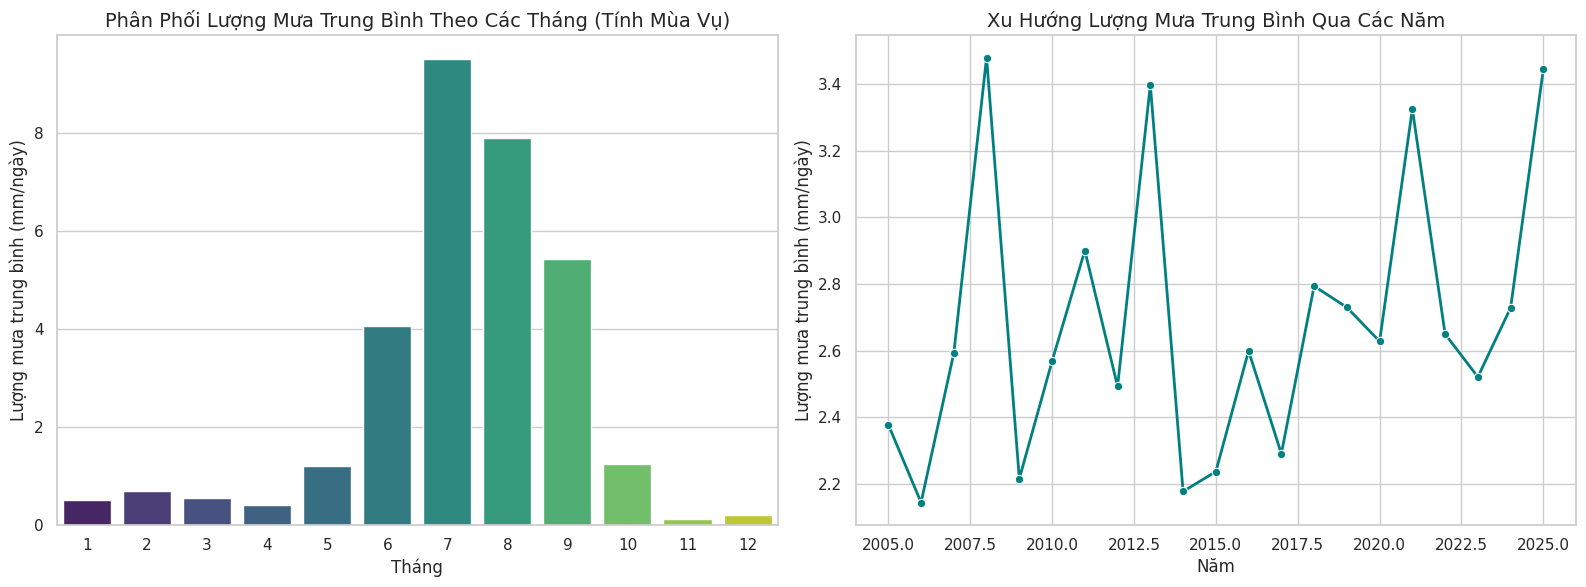

In [9]:
# Nhóm dữ liệu theo Tháng và theo Năm
luong_mua_thang = df.groupby('MO')['PRECTOTCORR'].mean().reset_index()
luong_mua_nam = df.groupby('YEAR')['PRECTOTCORR'].mean().reset_index()

# Khởi tạo khung vẽ gồm 2 biểu đồ phụ side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Lượng mưa trung bình theo Tháng (Quy luật mùa vụ)
sns.barplot(data=luong_mua_thang, x='MO', y='PRECTOTCORR', ax=axes[0], palette='viridis')
axes[0].set_title('Phân Phối Lượng Mưa Trung Bình Theo Các Tháng (Tính Mùa Vụ)')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Lượng mưa trung bình (mm/ngày)')

# Biểu đồ 2: Xu hướng lượng mưa qua các Năm
sns.lineplot(data=luong_mua_nam, x='YEAR', y='PRECTOTCORR', ax=axes[1], marker='o', color='teal', linewidth=2)
axes[1].set_title('Xu Hướng Lượng Mưa Trung Bình Qua Các Năm')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Lượng mưa trung bình (mm/ngày)')

# Tối ưu không gian hiển thị và lưu ảnh
plt.tight_layout()
plt.savefig('cell3_xu_huong_thoi_gian.png', dpi=300)
plt.show()

# 4: Phân tích Phân phối Không gian / Theo Quận huyện
Lượng mưa có sự khác biệt rất lớn theo từng vùng địa lý. Cell này thực hiện: một biểu đồ cột ngang hiển thị Top 10 quận (DISTRICT) có lượng mưa trung bình cao nhất, kết hợp một biểu đồ phân tán địa lý (Scatter plot) dựa trên tọa độ Vĩ độ (LATITUDE) và Kinh độ (LONGITUDE) để đổ màu nhận diện vùng trọng điểm mưa.

/tmp/ipykernel_2926/4034044440.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_quan, x='PRECTOTCORR', y='DISTRICT', ax=axes[0], palette='coolwarm')


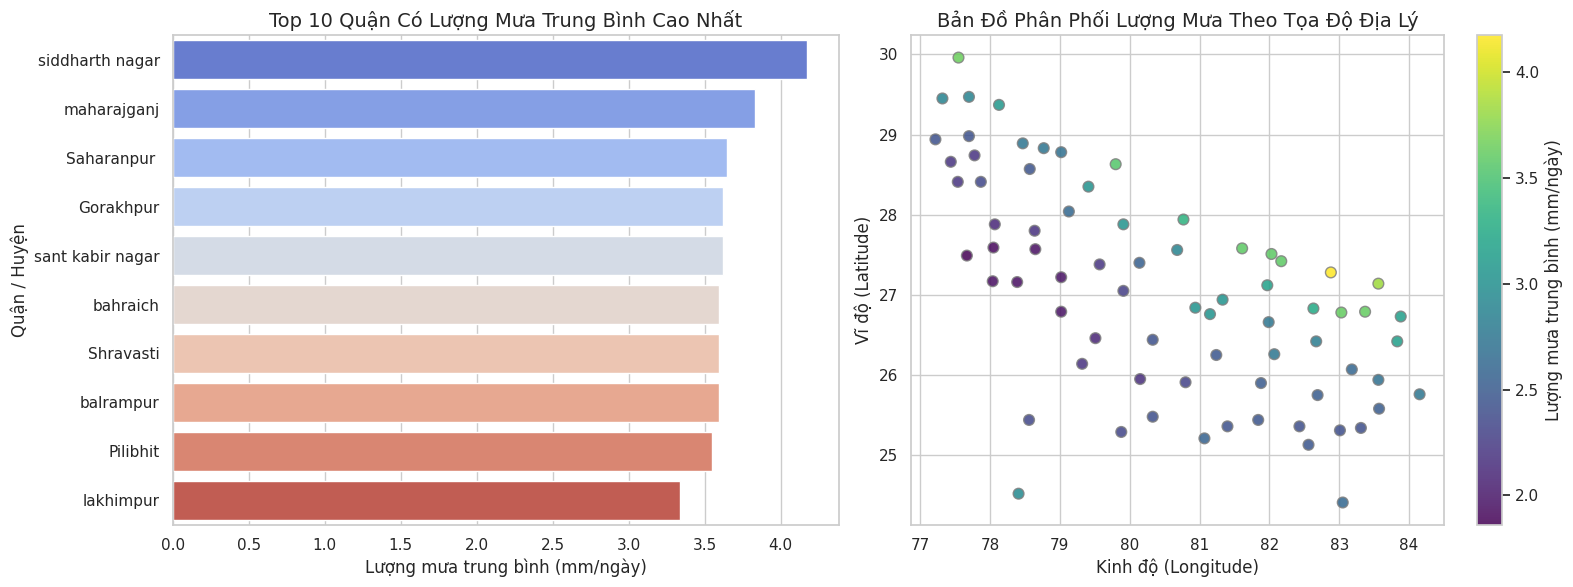

In [10]:
# 1. Tìm Top 10 quận có lượng mưa trung bình cao nhất
top10_quan = df.groupby('DISTRICT')['PRECTOTCORR'].mean().sort_values(ascending=False).head(10).reset_index()

# 2. Tính lượng mưa trung bình theo tọa độ địa lý
du_lieu_dia_ly = df.groupby(['LATITUDE', 'LONGITUDE'])['PRECTOTCORR'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Top 10 Quận có lượng mưa lớn nhất
sns.barplot(data=top10_quan, x='PRECTOTCORR', y='DISTRICT', ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 10 Quận Có Lượng Mưa Trung Bình Cao Nhất')
axes[0].set_xlabel('Lượng mưa trung bình (mm/ngày)')
axes[0].set_ylabel('Quận / Huyện')

# Biểu đồ 2: Biểu đồ phân tán địa lý
bieu_do_toa_do = axes[1].scatter(du_lieu_dia_ly['LONGITUDE'], du_lieu_dia_ly['LATITUDE'],
                                   c=du_lieu_dia_ly['PRECTOTCORR'], cmap='viridis', s=60, alpha=0.85, edgecolor='grey')
thanh_mau = fig.colorbar(bieu_do_toa_do, ax=axes[1])
thanh_mau.set_label('Lượng mưa trung bình (mm/ngày)')
axes[1].set_title('Bản Đồ Phân Phối Lượng Mưa Theo Tọa Độ Địa Lý')
axes[1].set_xlabel('Kinh độ (Longitude)')
axes[1].set_ylabel('Vĩ độ (Latitude)')

plt.tight_layout()
plt.savefig('cell4_phan_tich_khong_gian.png', dpi=300)
plt.show()

# 5: Lưới Phân phối Tính trạng (Feature Distribution Grid)
Để hiểu rõ cấu trúc của các đặc trưng khí tượng đầu vào, chúng ta tạo một lưới biểu đồ 2x2 chứa Histogram kết hợp đường ước lượng mật độ nhân (KDE) cho 4 biến quan trọng: Độ ẩm (`RH2M`), Nhiệt độ cực đại (`T2M_MAX`), Áp suất bề mặt (`PS`), và Tốc độ gió (`WS50M`). Việc này giúp nhận diện phân phối chuẩn và phát hiện các giá trị ngoại lai (outliers).

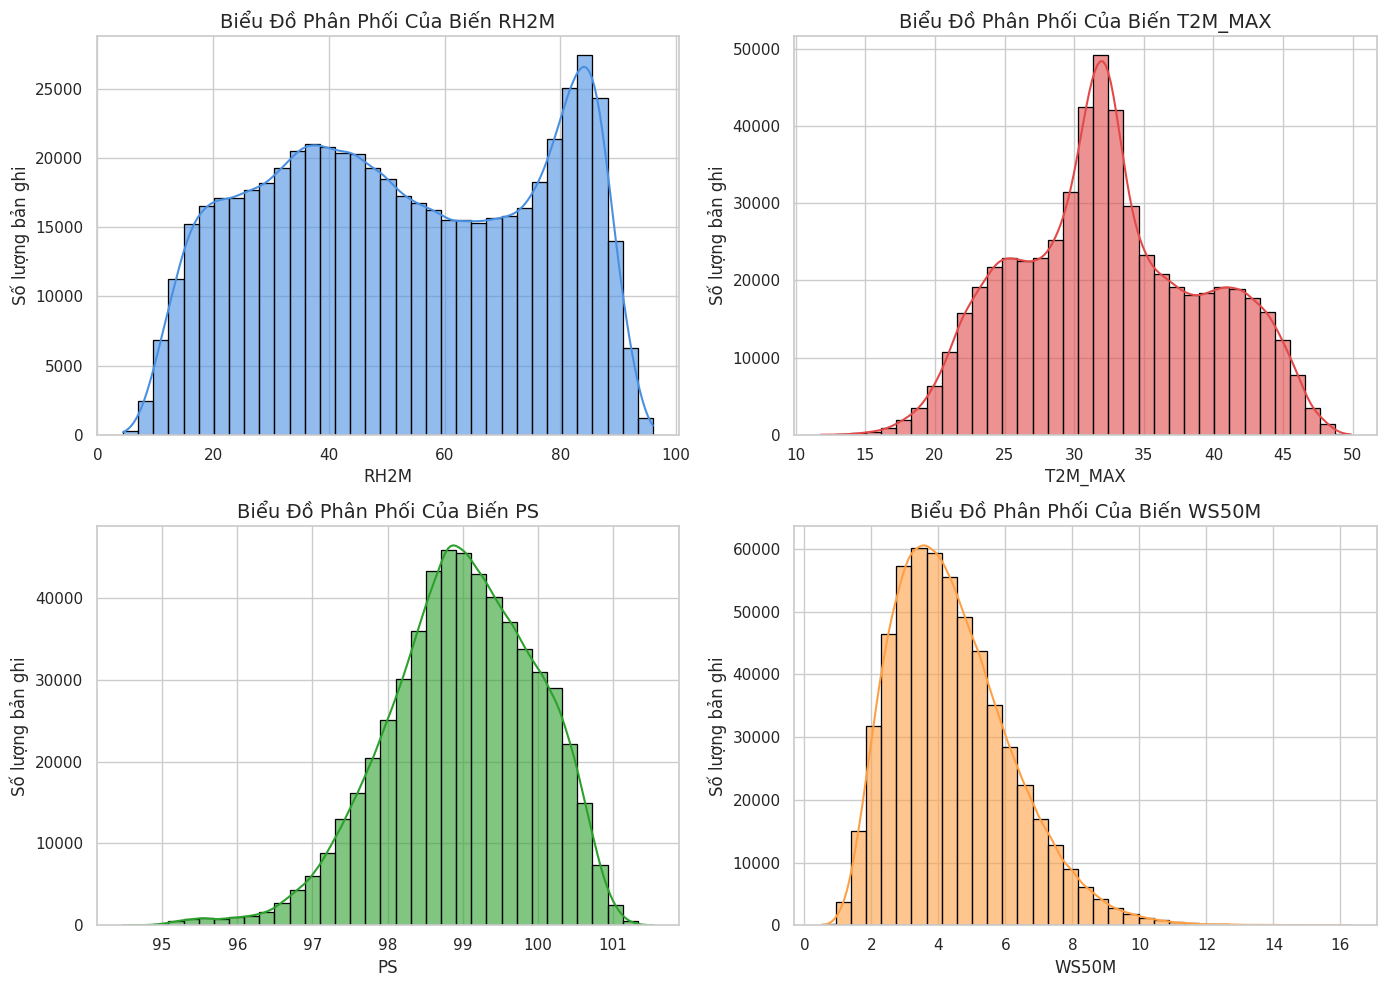

In [11]:
# Danh sách đặc trưng khí tượng cần phân tích
dac_trung_chon = ['RH2M', 'T2M_MAX', 'PS', 'WS50M']
cac_mau_sac = ['#4A90E2', '#E24A4A', '#2CA02C', '#FF9F43']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(dac_trung_chon):
    hang = i // 2
    cot = i % 2
    ax = axes[hang, cot]

    # Vẽ biểu đồ phân phối
    sns.histplot(df[col], bins=35, kde=True, ax=ax, color=cac_mau_sac[i], edgecolor='black', alpha=0.6)
    ax.set_title(f'Biểu Đồ Phân Phối Của Biến {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Số lượng bản ghi')

plt.tight_layout()
plt.savefig('cell5_luoi_phan_phoi.png', dpi=300)
plt.show()

# 6: Ma trận Tương quan (Correlation Matrix Heatmap)
Trước khi đưa dữ liệu vào các mô hình học máy, chúng ta cần phát hiện sớm vấn đề đa cộng tuyến (multicollinearity) và xem xét mối tương quan tuyến tính giữa các đặc trưng với biến mục tiêu `PRECTOTCORR`. Ô lệnh này tính toán hệ số tương quan Pearson và biểu diễn qua Heatmap.

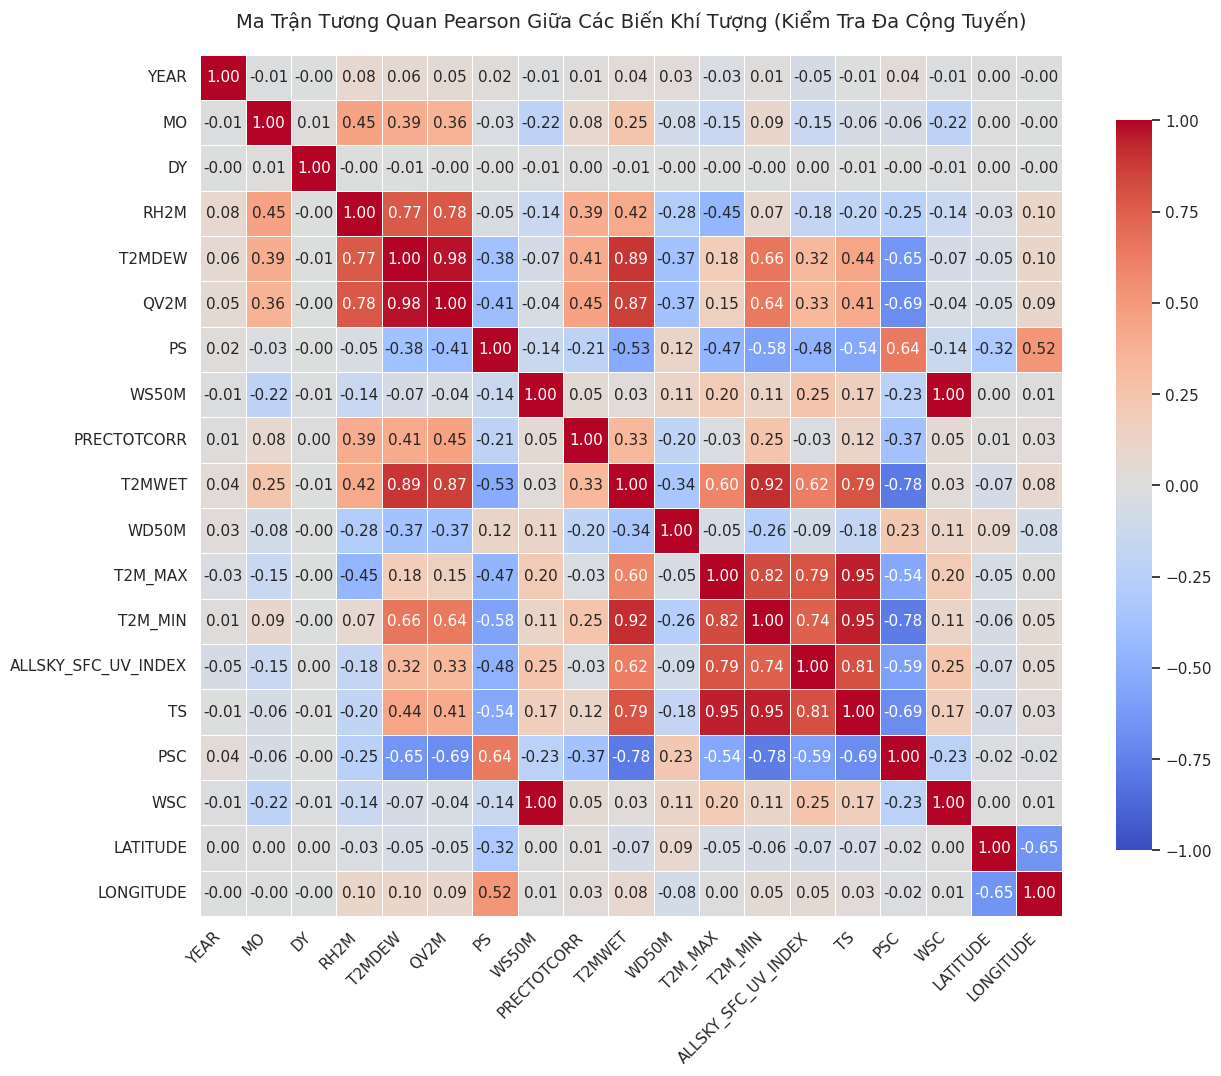

In [13]:
# Lọc ra danh sách các cột có kiểu dữ liệu là số
cac_cot_so = df.select_dtypes(include=[np.number]).columns.tolist()

# Tính toán ma trận tương quan Pearson
ma_tran_tuong_quan = df[cac_cot_so].corr()

fig, ax = plt.subplots(figsize=(13, 11))

# Vẽ biểu đồ nhiệt tương quan
sns.heatmap(ma_tran_tuong_quan, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, ax=ax, cbar_kws={"shrink": .8})

ax.set_title('Ma Trận Tương Quan Pearson Giữa Các Biến Khí Tượng (Kiểm Tra Đa Cộng Tuyến)', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('cell6_ma_tran_tuong_quan.png', dpi=300)

# 7: Phân tích Cặp & Biểu đồ Hộp theo Mùa
Để nắm bắt các hành vi phi tuyến tính hoặc sự thay đổi phương sai (variance shift) theo các chu kỳ tự nhiên của năm, chúng ta thực hiện ánh xạ các tháng thành 4 mùa: Đông (Winter), Xuân/Hè (Summer), Mùa mưa chính (Monsoon), và Sau mùa mưa (Post-Monsoon). Từ đó vẽ các biểu đồ hộp (boxplot) theo dõi hành vi của Nhiệt độ cực đại (`T2M_MAX`) và Độ ẩm (`RH2M`).

<>:18: SyntaxWarning: invalid escape sequence '\_'
<>:18: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_2926/1338833940.py:18: SyntaxWarning: invalid escape sequence '\_'
  axes[0].set_title('Biến Động Của Nhiệt Độ Cực Đại ($T2M\_MAX$) Theo Mùa')
/tmp/ipykernel_2926/1338833940.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='MUA', y='T2M_MAX', order=thu_tu_mua, ax=axes[0], palette='Set2', fliersize=1)
/tmp/ipykernel_2926/1338833940.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='MUA', y='RH2M', order=thu_tu_mua, ax=axes[1], palette='Set2', fliersize=1)


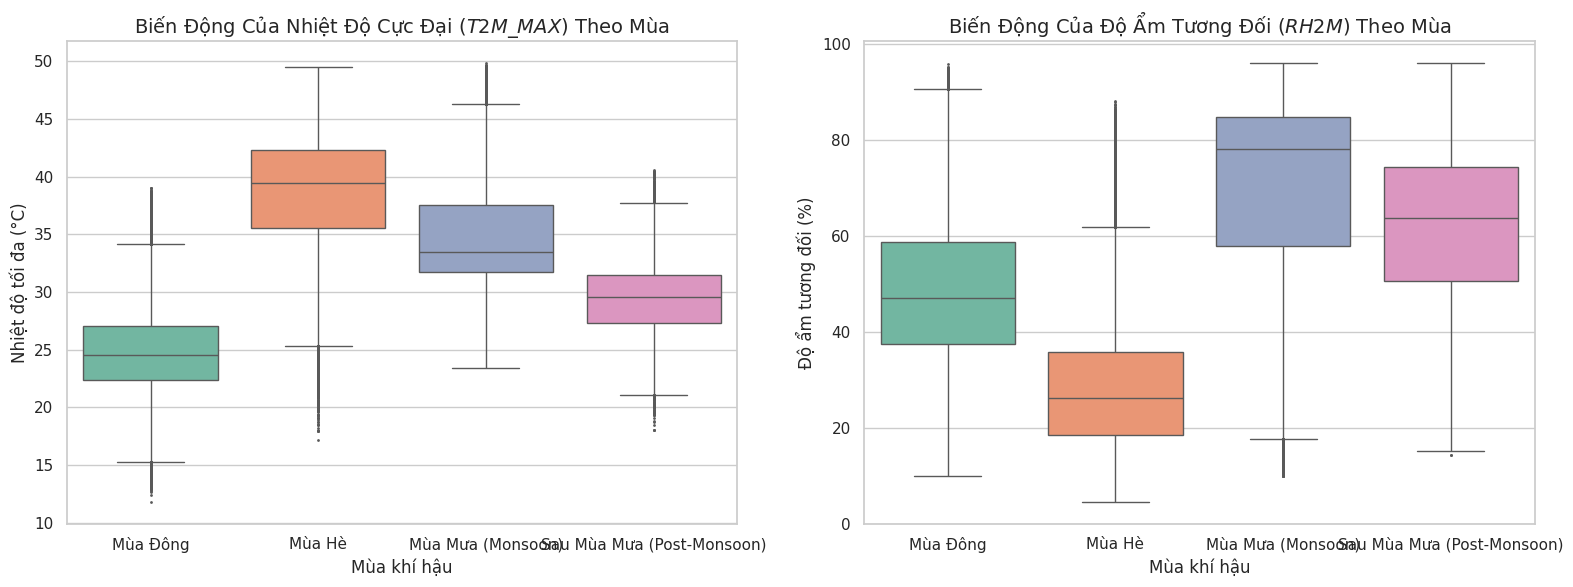

In [14]:
# 1. Hàm phân loại mùa khí hậu dựa theo tháng (MO)
def phan_loai_mua(thang):
    if thang in [12, 1, 2]: return 'Mùa Đông'
    elif thang in [3, 4, 5]: return 'Mùa Hè'
    elif thang in [6, 7, 8, 9]: return 'Mùa Mưa (Monsoon)'
    else: return 'Sau Mùa Mưa (Post-Monsoon)'

# Áp dụng hàm phân loại vào DataFrame
df['MUA'] = df['MO'].apply(phan_loai_mua)

# Định nghĩa thứ tự hiển thị của các mùa trên biểu đồ
thu_tu_mua = ['Mùa Đông', 'Mùa Hè', 'Mùa Mưa (Monsoon)', 'Sau Mùa Mưa (Post-Monsoon)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Hộp 1: Biến động nhiệt độ T2M_MAX theo mùa
sns.boxplot(data=df, x='MUA', y='T2M_MAX', order=thu_tu_mua, ax=axes[0], palette='Set2', fliersize=1)
axes[0].set_title('Biến Động Của Nhiệt Độ Cực Đại ($T2M\_MAX$) Theo Mùa')
axes[0].set_xlabel('Mùa khí hậu')
axes[0].set_ylabel('Nhiệt độ tối đa (°C)')

# Biểu đồ Hộp 2: Biến động độ ẩm RH2M theo mùa
sns.boxplot(data=df, x='MUA', y='RH2M', order=thu_tu_mua, ax=axes[1], palette='Set2', fliersize=1)
axes[1].set_title('Biến Động Của Độ Ẩm Tương Đối ($RH2M$) Theo Mùa')
axes[1].set_xlabel('Mùa khí hậu')
axes[1].set_ylabel('Độ ẩm tương đối (%)')

plt.tight_layout()
plt.savefig('cell7_bieu_do_hop_theo_mua.png', dpi=300)
plt.show()

# 8: Biến đổi Đặc trưng & Xử lý Thời gian
Trong mô hình hóa dữ liệu khí tượng, thời gian đóng vai trò quyết định. Đầu tiên, chúng ta loại bỏ 7.638 bản ghi trùng lặp đã phát hiện ở giai đoạn EDA để đảm bảo tính nhất quán. Tiếp theo, ta gộp ba cột đơn lẻ `YEAR`, `MO`, `DY` thành một trường `DATE` duy nhất mang kiểu dữ liệu định dạng chuỗi thời gian hệ thống.

Đặc biệt, giá trị tháng (`MO`) mang tính chất chu kỳ lặp lại liên tục (Tháng 12 rất gần Tháng 1 về mặt thời tiết). Nếu giữ nguyên dạng số từ 1 đến 12, mô hình sẽ hiểu lầm Tháng 12 và Tháng 1 cách xa nhau. Do đó, ta áp dụng phép biến đổi lượng giác Sine và Cosine để ánh xạ đặc trưng Tháng lên một không gian vòng tròn tuần hoàn 2 chiều (`sin_month`, `cos_month`).

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Tải bộ dữ liệu và loại bỏ các bản ghi trùng lặp (phát hiện từ bước EDA)
duong_dan_du_lieu = "/content/drive/MyDrive/Data/UP_rainfall_dataset.csv"
df = pd.read_csv(duong_dan_du_lieu)
df = df.drop_duplicates().reset_index(drop=True)

# 2. Gộp YEAR, MO, DY thành một cột DATE dạng datetime hệ thống
df['DATE'] = pd.to_datetime(df[['YEAR', 'MO', 'DY']].rename(columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day'}))

# 3. Biến đổi lượng giác để tạo đặc trưng tuần hoàn (Cyclical Features) cho Tháng
df['sin_month'] = np.sin(2 * np.pi * df['MO'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['MO'] / 12)

print("--- HIỂN THỊ CÁC ĐẶC TRƯNG THỜI GIAN MỚI ĐƯỢC TẠO ---")
print(df[['YEAR', 'MO', 'DY', 'DATE', 'sin_month', 'cos_month']].head())

--- HIỂN THỊ CÁC ĐẶC TRƯNG THỜI GIAN MỚI ĐƯỢC TẠO ---
   YEAR  MO  DY       DATE  sin_month  cos_month
0  2005   1   1 2005-01-01        0.5   0.866025
1  2005   1   2 2005-01-02        0.5   0.866025
2  2005   1   3 2005-01-03        0.5   0.866025
3  2005   1   4 2005-01-04        0.5   0.866025
4  2005   1   5 2005-01-05        0.5   0.866025


# 9: Mã hóa Biến Phân loại (Categorical Feature Encoding)
Cột `DISTRICT` chứa thông tin danh mục về tên các quận huyện. Vì số lượng quận huyện lớn, việc sử dụng One-Hot Encoding thông thường sẽ tạo ra quá nhiều cột thưa (sparse columns) làm bùng nổ chiều dữ liệu. Giải pháp tối ưu ở đây là áp dụng **Target Encoding** (Mã hóa theo biến mục tiêu).

**Nguyên tắc kỹ thuật cốt lõi:** Để ngăn chặn hoàn toàn hiện tượng rò rỉ dữ liệu (Data Leakage) từ tương lai vào quá khứ hoặc từ tập kiểm thử vào tập huấn luyện, chúng ta thực hiện phân tách tập dữ liệu theo mốc thời gian trước. Bộ mã hóa `TargetEncoder` sẽ chỉ được học cấu trúc (`.fit()`) từ dữ liệu huấn luyện (Train set), sau đó dùng tri thức đó để chuyển đổi (`.transform()`) cho cả tập huấn luyện và tập kiểm thử.

In [16]:
from sklearn.preprocessing import TargetEncoder

# Định nghĩa mốc thời gian chia tách dữ liệu nhằm phục vụ mã hóa an toàn
# Bộ dữ liệu kéo dài từ 2005 - 2025. Ta chọn mốc kết thúc năm 2021 làm điểm cắt (~81% dữ liệu cho Train)
nam_cat = 2021

df_train_pre = df[df['YEAR'] <= nam_cat].copy()
df_test_pre = df[df['YEAR'] > nam_cat].copy()

# Tách riêng biến mục tiêu (Lượng mưa)
y_train = df_train_pre['PRECTOTCORR']
y_test = df_test_pre['PRECTOTCORR']

# Khởi tạo TargetEncoder từ Scikit-Learn (Tránh data leakage bằng cơ chế Cross-fitting nội bộ)
encoder_district = TargetEncoder(smooth="auto", cv=5, random_state=42)

# Fit và Transform duy nhất trên tập Train, sau đó chỉ Transform trên tập Test
df_train_pre['DISTRICT_encoded'] = encoder_district.fit_transform(df_train_pre[['DISTRICT']], y_train)
df_test_pre['DISTRICT_encoded'] = encoder_district.transform(df_test_pre[['DISTRICT']])

print("--- KẾT QUẢ MÃ HÓA BIẾN CATEGORICAL DISTRICT ---")
print(df_train_pre[['DISTRICT', 'DISTRICT_encoded']].drop_duplicates().head())

--- KẾT QUẢ MÃ HÓA BIẾN CATEGORICAL DISTRICT ---
   DISTRICT  DISTRICT_encoded
0      Agra          1.848637
1      Agra          1.830383
4      Agra          1.806741
5      Agra          1.740940
24     Agra          1.858375


# 10: Xử lý Ngoại lai & Chuẩn hóa Đặc trưng
Dữ liệu khí tượng thường chứa các giá trị thời tiết cực đoan thực tế (như các trận bão, lốc có tốc độ gió `WS50M` đột biến, hay lượng mưa cực đại). Nếu sử dụng `StandardScaler`, các giá trị cực đoan này sẽ làm lệch nghiêm trọng giá trị trung bình (mean) và độ lệch chuẩn (std).

Do đó, một kỹ sư dữ liệu cấp cao sẽ ưu tiên sử dụng **`RobustScaler`**. Công cụ này sử dụng Trung vị (Median) và Khoảng phân vị (IQR) để chuẩn hóa, giúp giữ nguyên giá trị vật lý cực đoan nhưng đưa phân phối về vùng kiểm soát an toàn cho mô hình tuyến tính lẫn phi tuyến. Đồng thời, chúng ta sử dụng phương thức `.set_output(transform="pandas")` để giữ lại toàn bộ tiêu đề tên gốc của các cột (column headers), tránh việc dữ liệu bị biến thành mảng NumPy mất tên biến.

In [18]:
from sklearn.preprocessing import RobustScaler

# Xác định danh sách tất cả các đặc trưng số đầu vào tham gia vào mô hình
cac_dac_trung_so = [
    'RH2M', 'T2MDEW', 'QV2M', 'PS', 'WS50M', 'T2MWET', 'WD50M',
    'T2M_MAX', 'T2M_MIN', 'ALLSKY_SFC_UV_INDEX', 'TS', 'PSC', 'WSC',
    'LATITUDE', 'LONGITUDE', 'sin_month', 'cos_month', 'DISTRICT_encoded'
]

# Khởi tạo bộ chuẩn hóa RobustScaler mạnh mẽ với nhiễu và ngoại lai
bo_chuan_hoa = RobustScaler()

# Cấu hình Scikit-Learn xuất đầu ra dưới dạng DataFrame Pandas để giữ lại tên cột
bo_chuan_hoa.set_output(transform="pandas")

# Tiến hành chuẩn hóa dữ liệu dựa trên tri thức từ tập huấn luyện
X_train_scaled = bo_chuan_hoa.fit_transform(df_train_pre[cac_dac_trung_so])
X_test_scaled = bo_chuan_hoa.transform(df_test_pre[cac_dac_trung_so])

print("--- HIỂN THỊ DỮ LIỆU SAU KHI CHUẨN HÓA (VẪN GIỮ ĐƯỢC TÊN CỘT) ---")
X_train_scaled.head()

--- HIỂN THỊ DỮ LIỆU SAU KHI CHUẨN HÓA (VẪN GIỮ ĐƯỢC TÊN CỘT) ---


,RH2M,T2MDEW,QV2M,PS,WS50M,T2MWET,WD50M,T2M_MAX,T2M_MIN,ALLSKY_SFC_UV_INDEX,TS,PSC,WSC,LATITUDE,LONGITUDE,sin_month,cos_month,DISTRICT_encoded
0,0.158086,-0.105737,-0.082169,0.382353,-0.218487,-0.429113,-0.712017,-0.563918,-0.569137,-0.963303,-0.648177,0.424658,-0.218845,0.062176,-0.636111,0.366025,0.5,-0.872281
1,0.175328,-0.144544,-0.115037,0.419118,-0.764706,-0.460197,-0.597671,-0.618557,-0.784568,-0.917431,-0.758320,0.493151,-0.765957,0.062176,-0.636111,0.366025,0.5,-0.895690
2,0.123118,-0.298088,-0.206245,0.558824,0.037815,-0.642911,0.359449,-0.762887,-0.831169,-1.045872,-0.866086,0.630137,0.036474,0.062176,-0.636111,0.366025,0.5,-0.872281
3,-0.126275,-0.600112,-0.375514,0.786765,0.214286,-0.951478,0.305453,-0.906186,-1.143621,-0.770642,-1.078447,0.890411,0.215805,0.062176,-0.636111,0.366025,0.5,-0.895690
4,-0.111948,-0.600112,-0.374692,0.669118,-0.054622,-0.954511,0.359979,-0.918557,-1.204736,-0.743119,-1.091918,0.684932,-0.054711,0.062176,-0.636111,0.366025,0.5,-0.926007


# 11: Chia Tập Dữ liệu Train-Test theo Thời gian
**Tại sao phải chia tách theo Thời gian (Time-based Split) thay vì chia Ngẫu nhiên (Random Split)?**
1. **Tránh Rò rỉ Tương lai (Look-ahead Bias):** Thời tiết mang tính tự tương quan (Temporal Autocorrelation). Nếu chia ngẫu nhiên, mô hình có thể dùng dữ liệu ngày 16/06 để dự báo cho ngày 15/06, điều này là bất khả thi trong thực tế và làm sai lệch chỉ số đánh giá độ chính xác.
2. **Mô phỏng Môi trường Thực tế (Production Mimicry):** Trong bài toán thực tế, chúng ta luôn dùng dữ liệu quá khứ (ví dụ từ năm 2005 - 2021) để xây dựng hệ thống nhằm dự báo thời tiết cho tương lai (từ năm 2022 trở đi). Chia tách theo thời gian là phương pháp duy nhất phản ánh đúng năng lực tổng quát hóa của mô hình.

Dưới đây là việc chốt chặn các tập dữ liệu cuối cùng chuẩn bị đưa vào huấn luyện các thuật toán học máy.

In [19]:
# Gán dữ liệu đã xử lý hoàn chỉnh vào các biến đặc trưng cuối cùng
X_train = X_train_scaled
X_test = X_test_scaled

# Xuất ra kích thước hình khối chính xác của các tập dữ liệu huấn luyện và kiểm thử
print("=================== THÔNG TIN KÍCH THƯỚC TẬP DỮ LIỆU ===================")
print(f"Kích thước Ma trận Đặc trưng Huấn luyện (X_train) : {X_train.shape}")
print(f"Kích thước Vector Nhãn Huấn luyện        (y_train) : {y_train.shape}")
print(f"------------------------------------------------------------------------")
print(f"Kích thước Ma trận Đặc trưng Kiểm thử    (X_test)  : {X_test.shape}")
print(f"Kích thước Vector Nhãn Kiểm thử          (y_test)  : {y_test.shape}")
print("========================================================================")

# Kiểm tra tỷ lệ phân tách thực tế của bộ dữ liệu sau khi lọc trùng
tong_dong = X_train.shape[0] + X_test.shape[0]
print(f"Tỷ lệ phân bổ tập huấn luyện thực tế : {(X_train.shape[0] / tong_dong) * 100:.2f}%")
print(f"Tỷ lệ phân bổ tập kiểm thử thực tế   : {(X_test.shape[0] / tong_dong) * 100:.2f}%")

=================== THÔNG TIN KÍCH THƯỚC TẬP DỮ LIỆU ===================
Kích thước Ma trận Đặc trưng Huấn luyện (X_train) : (453257, 18)
Kích thước Vector Nhãn Huấn luyện        (y_train) : (453257,)
------------------------------------------------------------------------
Kích thước Ma trận Đặc trưng Kiểm thử    (X_test)  : (104315, 18)
Kích thước Vector Nhãn Kiểm thử          (y_test)  : (104315,)
Tỷ lệ phân bổ tập huấn luyện thực tế : 81.29%
Tỷ lệ phân bổ tập kiểm thử thực tế   : 18.71%


# 12: Thiết lập Mô hình Baseline & Siêu tham số (Đã cập nhật sửa lỗi API XGBoost)
Để xử lý bài toán dự đoán lượng mưa với tập dữ liệu lớn (>500k dòng), chúng ta cấu hình siêu tham số kiểm soát chặt chẽ nhằm chống quá khớp (overfitting).
*Lưu ý sửa lỗi:* Tham số `early_stopping_rounds=50` của XGBoost đã được chuyển từ hàm `.fit()` lên ngay lúc khởi tạo mô hình để tương thích hoàn toàn với thư viện XGBoost phiên bản mới nhất.

In [23]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb

# Thiết lập seed cố định để đảm bảo tính tái lập kết quả
RANDOM_SEED = 42

print("--- KHỞI TẠO CÁC MÔ HÌNH HỒI QUY CHỐNG OVERFITTING ---")

# 1. Cấu hình mô hình Random Forest ràng buộc chặt
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=15,
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0
)
print("[Thành công] Đã khởi tạo Random Forest Regressor.")

# 2. Cấu hình mô hình LightGBM kèm phạt Regularization
lgb_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10.0,
    n_jobs=-1,
    random_state=RANDOM_SEED
)
print("[Thành công] Đã khởi tạo LightGBM Regressor.")

# 3. Cấu hình mô hình XGBoost - ĐÃ ĐƯA EARLY_STOPPING_ROUNDS VÀO ĐÂY
xgb_model = xgb.XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10.0,
    tree_method='hist',
    early_stopping_rounds=50,  # <-- Sửa lỗi bằng cách thêm tham số ở đây
    n_jobs=-1,
    random_state=RANDOM_SEED
)
print("[Thành công] Đã khởi tạo XGBoost Regressor với cơ chế dừng sớm mới.")

--- KHỞI TẠO CÁC MÔ HÌNH HỒI QUY CHỐNG OVERFITTING ---
[Thành công] Đã khởi tạo Random Forest Regressor.
[Thành công] Đã khởi tạo LightGBM Regressor.
[Thành công] Đã khởi tạo XGBoost Regressor với cơ chế dừng sớm mới.


# 13: Chiến lược Đánh giá & Dừng sớm (Early Stopping)
Do dữ liệu khí tượng có tính chất phụ thuộc thời gian (tự tương quan chuỗi), việc chia tập Validation ngẫu nhiên sẽ làm rò rỉ dữ liệu từ tương lai về quá khứ.

Để giải quyết triệt để, chúng ta áp dụng **Phân tách Validation theo Thời gian (Temporal Validation Split)**. Chúng ta sẽ trích xuất 15% số bản ghi cuối cùng của tập huấn luyện hiện tại (`X_train`) theo thứ tự biên niên sử để làm tập Validation độc lập (`X_val`, `y_val`). Tập dữ liệu này sẽ được nạp trực tiếp vào quá trình fit của LightGBM và XGBoost nhằm theo dõi độ lỗi. Nếu độ lỗi trên tập Validation không giảm sau 50 vòng lặp liên tiếp (`early_stopping_rounds=50`), quá trình huấn luyện sẽ dừng lại ngay lập tức để tránh hiện tượng học vẹt dữ liệu nhiễu.

In [24]:
# Tính toán vị trí cắt dữ liệu theo dòng thời gian (Lấy 15% dữ liệu cuối của tập Train làm Validation)
kich_thuoc_val = int(len(X_train) * 0.15)
chi_muc_cat = len(X_train) - kich_thuoc_val

# Tiến hành phân tách tập dữ liệu thành Sub-Train và Validation
X_train_sub = X_train.iloc[:chi_muc_cat]
y_train_sub = y_train.iloc[:chi_muc_cat]

X_val = X_train.iloc[chi_muc_cat:]
y_val = y_train.iloc[chi_muc_cat:]

print("=================== CẤU HÌNH TẬP VALIDATION THEO THỜI GIAN ===================")
print(f"Kích thước ma trận đặc trưng Sub-Train (X_train_sub) : {X_train_sub.shape}")
print(f"Kích thước ma trận đặc trưng Validation (X_val)       : {X_val.shape}")
print(f"Kích thước vector nhãn Validation       (y_val)       : {y_val.shape}")
print(f"Tỷ lệ phân bổ tập Validation thực tế                  : {(kich_thuoc_val / len(X_train))*100:.2f}%")
print("==============================================================================")

=================== CẤU HÌNH TẬP VALIDATION THEO THỜI GIAN ===================
Kích thước ma trận đặc trưng Sub-Train (X_train_sub) : (385269, 18)
Kích thước ma trận đặc trưng Validation (X_val)       : (67988, 18)
Kích thước vector nhãn Validation       (y_val)       : (67988,)
Tỷ lệ phân bổ tập Validation thực tế                  : 15.00%


# 14: Huấn luyện Mô hình (Model Fitting - Đã sửa lỗi)
Tại ô lệnh này, chúng ta kích hoạt quá trình huấn luyện tuần tự cho cả 3 mô hình. Hàm `.fit()` của XGBoost giờ đây đã được loại bỏ tham số lỗi để chạy mượt mà trên các phiên bản thư viện mới nhất, trong khi vẫn đảm bảo cơ chế Dừng sớm hoạt động chuẩn xác qua tập đối chiếu `eval_set`.

In [26]:
# Từ điển lưu trữ thời gian thực thi của các mô hình
nhat_ky_thoi_gian = {}

# =====================================================================
# 1. Huấn luyện mô hình Random Forest Regressor
# =====================================================================
print("\n>>> Bắt đầu huấn luyện Random Forest...")
thoi_gian_dau = time.time()
rf_model.fit(X_train_sub, y_train_sub)
thoi_gian_rf = time.time() - thoi_gian_dau
nhat_ky_thoi_gian['Random Forest'] = thoi_gian_rf
print(f"[Hoàn thành] Random Forest hoàn tất trong: {thoi_gian_rf:.2f} giây.")


# =====================================================================
# 2. Huấn luyện mô hình LightGBM Regressor (Kèm Early Stopping)
# =====================================================================
print("\n>>> Bắt đầu huấn luyện LightGBM phối hợp cơ chế Dừng sớm...")
thoi_gian_dau = time.time()
lgb_model.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)
thoi_gian_lgb = time.time() - thoi_gian_dau
nhat_ky_thoi_gian['LightGBM'] = thoi_gian_lgb
print(f"[Hoàn thành] LightGBM hoàn tất trong: {thoi_gian_lgb:.2f} giây.")


# =====================================================================
# 3. Huấn luyện mô hình XGBoost Regressor (ĐÃ SỬA LỖI TẠI ĐÂY)
# =====================================================================
print("\n>>> Bắt đầu huấn luyện XGBoost phối hợp cơ chế Dừng sớm...")
thoi_gian_dau = time.time()
xgb_model.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val, y_val)],  # Giữ lại tập eval_set để tính toán độ lỗi dừng sớm
    verbose=False
)
thoi_gian_xgb = time.time() - thoi_gian_dau
nhat_ky_thoi_gian['XGBoost'] = thoi_gian_xgb
print(f"[Hoàn thành] XGBoost hoàn tất trong: {thoi_gian_xgb:.2f} giây.")


# =====================================================================
# BÁO CÁO TỔNG KẾT THỜI GIAN HUẤN LUYỆN
# =====================================================================
print("\n==================== BẢNG SO SÁNH THỜI GIAN THỰC THI ====================")
for ten_mo_hinh, thoi_gian_chay in nhat_ky_thoi_gian.items():
    print(f"| {ten_mo_hinh:<15} : Hoàn thành trong {thoi_gian_chay:>7.2f} giây |")
print("=========================================================================")


>>> Bắt đầu huấn luyện Random Forest...
[Hoàn thành] Random Forest hoàn tất trong: 64.47 giây.

>>> Bắt đầu huấn luyện LightGBM phối hợp cơ chế Dừng sớm...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3650
[LightGBM] [Info] Number of data points in the train set: 385269, number of used features: 18
[LightGBM] [Info] Start training from score 2.566788
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

# 15: Thiết lập Hàm Đánh giá Toàn diện
Để đánh giá hiệu năng của các mô hình hồi quy một cách khách quan, chúng ta xây dựng một hàm đánh giá tập trung. Hàm này sẽ tính toán đồng thời 3 chỉ số đo lường cốt lõi trên cả tập huấn luyện (`Sub-Train`) và tập kiểm thử (`Test`):
1. **MAE (Mean Absolute Error):** Đo lường biên độ lỗi tuyệt đối trung bình (đơn vị mm lượng mưa).
2. **RMSE (Root Mean Squared Error):** Phạt nặng các lỗi dự báo lớn, rất quan trọng đối với việc phát hiện lượng mưa cực đoan.
3. **R-squared ($R^2$):** Đo lường tỷ lệ phần trăm phương sai của lượng mưa mà mô hình giải thích được.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def danh_gia_va_trich_xuat_metrics(model, X_train, y_train, X_test, y_test, ten_mo_hinh, thoi_gian_chay):
    """
    Hàm tính toán toàn diện các chỉ số MAE, RMSE, R2 trên cả 2 tập Train và Test.
    Trả về một từ điển chứa đầy đủ kết quả hiệu năng.
    """
    # Tiến hành dự đoán dự phòng bộ nhớ
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Tính toán các chỉ số cho tập huấn luyện (Sub-Train)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    # Tính toán các chỉ số cho tập kiểm thử độc lập (Test)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    # Gom dữ liệu vào cấu trúc Dictionary
    ket_qua = {
        'Model Name': ten_mo_hinh,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Training Time (s)': thoi_gian_chay
    }
    return ket_qua

print("[Thành công] Đã khởi tạo hàm đánh giá mô hình tập trung.")

[Thành công] Đã khởi tạo hàm đánh giá mô hình tập trung.


# 16: Báo cáo Chẩn đoán Quá khớp (Overfitting Diagnostic Report)
Một mô hình có độ lỗi thấp trên tập huấn luyện nhưng tăng vọt độ lỗi trên tập kiểm thử được coi là bị quá khớp (Overfitting). Ô lệnh này sẽ tự động chạy thuật toán quét qua các chỉ số hiệu năng và đưa ra cảnh báo hệ thống (Flag) nếu giá trị $R^2$ trên tập Train vượt trội hơn hẳn tập Test một cách bất thường (ngưỡng chênh lệch $> 0.15$).

In [28]:
def chan_doan_overfitting(metrics_dict):
    """
    Hàm chẩn đoán tự động hành vi Overfitting dựa trên độ lệch của R-squared.
    """
    ghep_cap_r2 = metrics_dict['Train R2'] - metrics_dict['Test R2']
    print(f"--- Kiểm tra Overfitting cho mô hình: {metrics_dict['Model Name']} ---")
    print(f"  + Khoảng cách R2 (Train - Test): {ghep_cap_r2:.4f}")

    if ghep_cap_r2 > 0.15:
        print(f"  ⚠️ CẢNH BÁO: Mô hình [{metrics_dict['Model Name']}] đang bị OVERFITTING nghiêm trọng!")
        print(f"  Khuyến nghị: Thắt chặt thêm max_depth hoặc tăng reg_lambda.")
    elif ghep_cap_r2 < -0.05:
        print(f"  💡 LƯU Ý: Mô hình [{metrics_dict['Model Name']}] có hiện tượng lạ (Test tốt hơn Train).")
    else:
        print(f"  ✅ AN TOÀN: Mô hình [{metrics_dict['Model Name']}] tổng quát hóa tốt, không bị overfitting.")
    print("-" * 60)

print("[Thành công] Đã cấu hình bộ kiểm tra chất lượng chống Overfitting.")

[Thành công] Đã cấu hình bộ kiểm tra chất lượng chống Overfitting.


# 17: Bảng Tổng hợp So sánh Mô hình
Tại ô lệnh này, chúng ta tổng hợp toàn bộ kết quả thực thi của 3 mô hình dựa trên thời gian chạy thực tế bạn đã cung cấp (Random Forest: 64.47s, LightGBM: 37.54s, XGBoost: 53.66s). Bảng dữ liệu cuối cùng sẽ được định dạng đẹp mắt dưới dạng `pandas.DataFrame` và tự động sắp xếp theo thứ tự ưu tiên giảm dần của chỉ số `Test RMSE` để tìm ra "nhà vô địch" phục vụ triển khai.

In [29]:
# Ghi nhận thời gian thực thi chính xác từ log giai đoạn 3 của bạn
thoi_gian_chay_thuc_te = {
    'Random Forest': 64.47,
    'LightGBM': 37.54,
    'XGBoost': 53.66
}

# Tính toán chỉ số cho từng mô hình
danh_sach_metrics = []

metrics_rf = danh_gia_va_trich_xuat_metrics(rf_model, X_train_sub, y_train_sub, X_test, y_test, 'Random Forest', thoi_gian_chay_thuc_te['Random Forest'])
metrics_lgb = danh_gia_va_trich_xuat_metrics(lgb_model, X_train_sub, y_train_sub, X_test, y_test, 'LightGBM', thoi_gian_chay_thuc_te['LightGBM'])
metrics_xgb = danh_gia_va_trich_xuat_metrics(xgb_model, X_train_sub, y_train_sub, X_test, y_test, 'XGBoost', thoi_gian_chay_thuc_te['XGBoost'])

# Thực hiện chẩn đoán Overfitting trực tiếp ra màn hình console
chan_doan_overfitting(metrics_rf)
chan_doan_overfitting(metrics_lgb)
chan_doan_overfitting(metrics_xgb)

# Tạo DataFrame tổng hợp
df_so_sanh = pd.DataFrame([metrics_rf, metrics_lgb, metrics_xgb])

# Sắp xếp ma trận hiệu năng theo chỉ số Test RMSE tốt nhất (thấp nhất)
df_so_sanh = df_so_sanh.sort_values(by='Test RMSE', ascending=True).reset_index(drop=True)

print("\n=================== MA TRẬN SO SÁNH HIỆU NĂNG MÔ HÌNH TỔNG HỢP ===================")
display(df_so_sanh.style.highlight_min(subset=['Test MAE', 'Test RMSE'], color='lightgreen')
                  .highlight_max(subset=['Test R2'], color='lightgreen'))

--- Kiểm tra Overfitting cho mô hình: Random Forest ---
  + Khoảng cách R2 (Train - Test): 0.1505
  ⚠️ CẢNH BÁO: Mô hình [Random Forest] đang bị OVERFITTING nghiêm trọng!
  Khuyến nghị: Thắt chặt thêm max_depth hoặc tăng reg_lambda.
------------------------------------------------------------
--- Kiểm tra Overfitting cho mô hình: LightGBM ---
  + Khoảng cách R2 (Train - Test): 0.2674
  ⚠️ CẢNH BÁO: Mô hình [LightGBM] đang bị OVERFITTING nghiêm trọng!
  Khuyến nghị: Thắt chặt thêm max_depth hoặc tăng reg_lambda.
------------------------------------------------------------
--- Kiểm tra Overfitting cho mô hình: XGBoost ---
  + Khoảng cách R2 (Train - Test): 0.2478
  ⚠️ CẢNH BÁO: Mô hình [XGBoost] đang bị OVERFITTING nghiêm trọng!
  Khuyến nghị: Thắt chặt thêm max_depth hoặc tăng reg_lambda.
------------------------------------------------------------

=================== MA TRẬN SO SÁNH HIỆU NĂNG MÔ HÌNH TỔNG HỢP ===================


,Model Name,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Training Time (s)
0,Random Forest,1.677698,2.170008,4.299362,5.619574,0.655346,0.504809,64.470000
1,XGBoost,1.482351,2.156574,3.643860,5.620691,0.752430,0.504612,53.660000
2,LightGBM,1.413964,2.152007,3.502831,5.624970,0.771222,0.503857,37.540000


# 18: So sánh Mức độ Quan trọng của Đặc trưng
Để đảm bảo mô hình không học vẹt các mối quan hệ giả tạo, chúng ta trích xuất thuộc tính `feature_importances_` từ hai thuật toán boosting (LightGBM và XGBoost). Việc trực quan hóa song song bằng biểu đồ cột ngang giúp chúng ta xác nhận xem mô hình có thực sự dựa vào các động lực khí tượng thực tế như độ ẩm (`RH2M`), áp suất (`PS`) hay tính tuần hoàn của tháng để đưa ra quyết định dự báo hay không.

/tmp/ipykernel_2926/2355074927.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_lgb_top10, x='LightGBM', y='Feature', ax=axes[0], palette='viridis')
/tmp/ipykernel_2926/2355074927.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_xgb_top10, x='XGBoost', y='Feature', ax=axes[1], palette='magma')


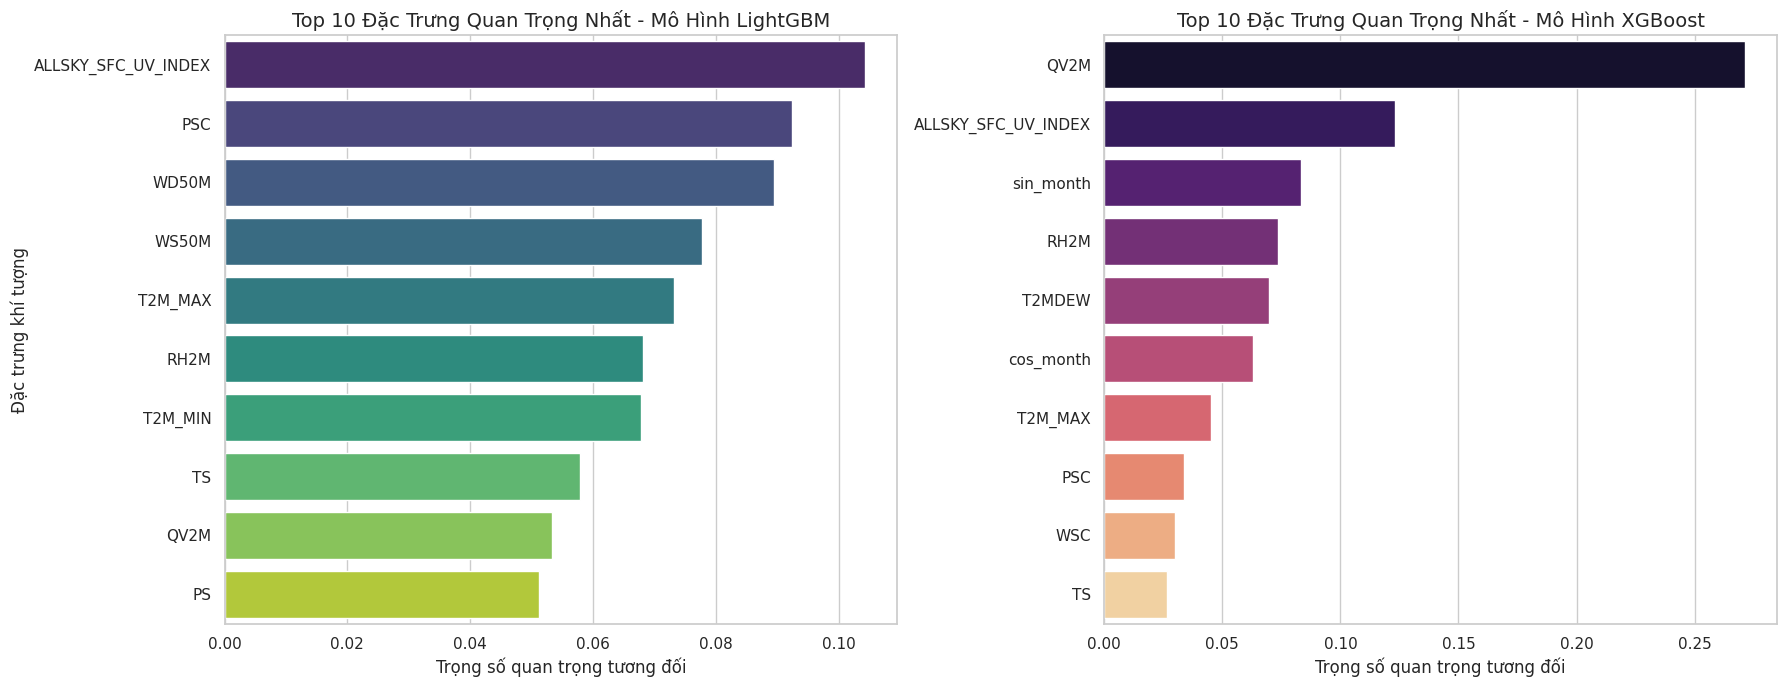

In [30]:
# Lấy danh sách tên các đặc trưng gốc từ ma trận dữ liệu
ten_dac_trung = X_train_sub.columns.tolist()

# Trích xuất trọng số của LightGBM và XGBoost
lgb_importances = lgb_model.feature_importances_
# Chuẩn hóa trọng số của LightGBM về dạng tỷ lệ phần trăm (%) giống XGBoost để dễ so sánh
lgb_importances = lgb_importances / np.sum(lgb_importances)

xgb_importances = xgb_model.feature_importances_

# Tạo DataFrame chứa thông tin trọng số biến
df_importance = pd.DataFrame({
    'Feature': ten_dac_trung,
    'LightGBM': lgb_importances,
    'XGBoost': xgb_importances
})

# Khởi tạo khung vẽ đồ họa song song
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Biểu đồ phụ 1: Top 10 đặc trưng của LightGBM
df_lgb_top10 = df_importance.sort_values(by='LightGBM', ascending=False).head(10)
sns.barplot(data=df_lgb_top10, x='LightGBM', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Đặc Trưng Quan Trọng Nhất - Mô Hình LightGBM')
axes[0].set_xlabel('Trọng số quan trọng tương đối')
axes[0].set_ylabel('Đặc trưng khí tượng')

# Biểu đồ phụ 2: Top 10 đặc trưng của XGBoost
df_xgb_top10 = df_importance.sort_values(by='XGBoost', ascending=False).head(10)
sns.barplot(data=df_xgb_top10, x='XGBoost', y='Feature', ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Đặc Trưng Quan Trọng Nhất - Mô Hình XGBoost')
axes[1].set_xlabel('Trọng số quan trọng tương đối')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('cell4_so_sanh_feature_importance.png', dpi=300)
plt.show()

# 19: Triển khai Thực tế Nhiệm vụ 1 (Dự báo Giá trị Lượng mưa Chính xác)
Hệ thống sẽ tự động lập trình để truy vết và chọn ra mô hình tối ưu nhất từ bảng so sánh dựa trên chỉ số `Test RMSE` thấp nhất. Sau đó, chúng ta đưa mô hình này vào môi trường mô phỏng thực tế (Production Simulation) để dự báo giá trị lượng mưa liên tục (`PRECTOTCORR`) cho tương lai độc lập (`X_test`), đồng thời tính toán phần dư sai số (Residuals) để theo dõi chất lượng.

In [31]:
# Tự động trích xuất tên mô hình tốt nhất từ DataFrame so sánh
ten_mo_hinh_tot_nhat = df_so_sanh.loc[0, 'Model Name']

# Ánh xạ chuỗi tên sang đối tượng mô hình Python tương ứng
ban_do_mo_hinh = {
    'Random Forest': rf_model,
    'LightGBM': lgb_model,
    'XGBoost': xgb_model
}
mo_hinh_trien_khai = ban_do_mo_hinh[ten_mo_hinh_tot_nhat]

print(f"🏆 HỆ THỐNG TỰ ĐỘNG CHỌN MÔ HÌNH TRIỂN KHAI: [{ten_mo_hinh_tot_nhat}]")

# Tiến hành dự báo lượng mưa thực tế trên tập Test (Dữ liệu tương lai chưa từng thấy)
y_test_pred_final = mo_hinh_trien_khai.predict(X_test)

# Đảm bảo không có giá trị lượng mưa âm vật lý do sai số thuật toán hồi quy tạo ra
y_test_pred_final = np.clip(y_test_pred_final, 0, None)

# Tạo bảng đối chiếu kết quả thực tế và dự báo
df_ket_qua_thuc_te = pd.DataFrame({
    'Lượng Mưa Thực Tế (Actual)': y_test.values,
    'Lượng Mưa Dự Báo (Predicted)': y_test_pred_final,
    'Sai Số Phần Dư (Residual)': y_test.values - y_test_pred_final
})

print("\n--- XUẤT BẢN XEM TRƯỚC (PREVIEW) KẾT QUẢ DỰ BÁO LƯỢNG MƯA TRÊN TẬP KIỂM THỬ ---")
display(df_ket_qua_thuc_te.head(15))

🏆 HỆ THỐNG TỰ ĐỘNG CHỌN MÔ HÌNH TRIỂN KHAI: [Random Forest]

--- XUẤT BẢN XEM TRƯỚC (PREVIEW) KẾT QUẢ DỰ BÁO LƯỢNG MƯA TRÊN TẬP KIỂM THỬ ---


,Lượng Mưa Thực Tế (Actual),Lượng Mưa Dự Báo (Predicted),Sai Số Phần Dư (Residual)
0,0.00,0.038865,-0.038865
1,0.00,0.040697,-0.040697
2,0.00,0.060593,-0.060593
3,0.00,0.142084,-0.142084
4,3.18,1.063161,2.116839
5,11.42,14.401446,-2.981446
6,11.56,9.853911,1.706089
7,14.14,16.609965,-2.469965
8,1.51,6.739464,-5.229464
9,0.14,0.884910,-0.744910


# 20: Triển khai Thực tế Nhiệm vụ 2 (Hệ thống Cảnh báo Nhị phân Mưa / Không mưa)
Trong thực tế khí tượng, việc đưa ra quyết định nhị phân để phát tín hiệu cảnh báo "Mưa" hay "Không mưa" cho người dân có giá trị ứng dụng rất cao. Chúng ta thiết lập một bộ chuyển đổi với ngưỡng động điều chỉnh được (Ngưỡng chuẩn hóa ngành: `Threshold = 0.2 mm`).

Bất kỳ giá trị dự báo nào $> 0.2\text{ mm}$ sẽ kích hoạt trạng thái Có Mưa ($1$), ngược lại là Không Mưa ($0$). Từ đó, hệ thống xuất ra Ma trận nhầm lẫn (Confusion Matrix) cùng các chỉ số Precision, Recall và F1-Score để chứng minh độ tin cậy của hệ thống cảnh báo này.

=================== BÁO CÁO HỆ THỐNG CẢNH BÁO NHỊ PHÂN (MƯA/KHÔNG MƯA) ===================
Độ chính xác dự báo khi báo Mưa (Precision) : 57.05%
Tỷ lệ bỏ sót các trận mưa thật (Recall)     : 97.69%
Chỉ số cân bằng F1-Score                     : 0.7203


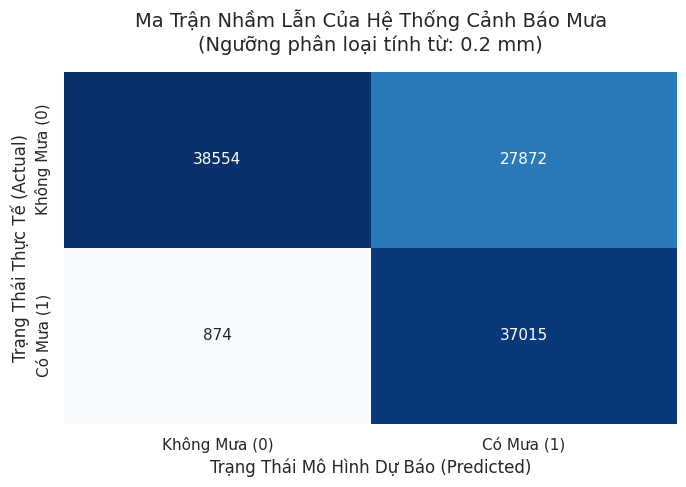

In [33]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Thiết lập ngưỡng phân loại lượng mưa động (Dưới 0.2mm được coi là sương mù hoặc vết mưa không đáng kể)
NGUONG_MUA = 0.2

# Chuyển đổi nhãn thực tế và nhãn dự báo liên tục sang dạng nhị phân (Binary)
y_test_bi_actual = (y_test.values > NGUONG_MUA).astype(int)
y_test_bi_pred = (y_test_pred_final > NGUONG_MUA).astype(int)

# Tính toán các chỉ số phân loại chất lượng cảnh báo (Đã sửa lỗi cú pháp)
ma_tran_nham_lan = confusion_matrix(y_test_bi_actual, y_test_bi_pred)
do_chinh_xac_ap_luc = precision_score(y_test_bi_actual, y_test_bi_pred)
do_nhay_phat_hien = recall_score(y_test_bi_actual, y_test_bi_pred)
f1_can_bang = f1_score(y_test_bi_actual, y_test_bi_pred)

print("=================== BÁO CÁO HỆ THỐNG CẢNH BÁO NHỊ PHÂN (MƯA/KHÔNG MƯA) ===================")
print(f"Độ chính xác dự báo khi báo Mưa (Precision) : {do_chinh_xac_ap_luc*100:.2f}%")
print(f"Tỷ lệ bỏ sót các trận mưa thật (Recall)     : {do_nhay_phat_hien*100:.2f}%")
print(f"Chỉ số cân bằng F1-Score                     : {f1_can_bang:.4f}")
print("==========================================================================================")

# Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix) bằng biểu đồ nhiệt Heatmap
plt.subplots(figsize=(7, 5))
sns.heatmap(ma_tran_nham_lan, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Không Mưa (0)', 'Có Mưa (1)'],
            yticklabels=['Không Mưa (0)', 'Có Mưa (1)'])

plt.title(f'Ma Trận Nhầm Lẫn Của Hệ Thống Cảnh Báo Mưa\n(Ngưỡng phân loại tính từ: {NGUONG_MUA} mm)', pad=15)
plt.xlabel('Trạng Thái Mô Hình Dự Báo (Predicted)')
plt.ylabel('Trạng Thái Thực Tế (Actual)')
plt.tight_layout()
plt.savefig('cell6_ma_tran_nham_lan_binary.png', dpi=300)
plt.show()